In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter, HourLocator

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import torch
import torch.optim as optim
import torch.nn as nn

import random
import json

In [36]:
SEED = 42

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [37]:
df = pd.read_csv('./data/S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.head(5)

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [38]:
df = df.sort_values('date', ascending=True)
df.head(5)

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


In [40]:
df.describe()

,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [41]:
print('max target:', df['target'].max())
print('min target:', df['target'].min())

max target: 210.1
min target: 69.1


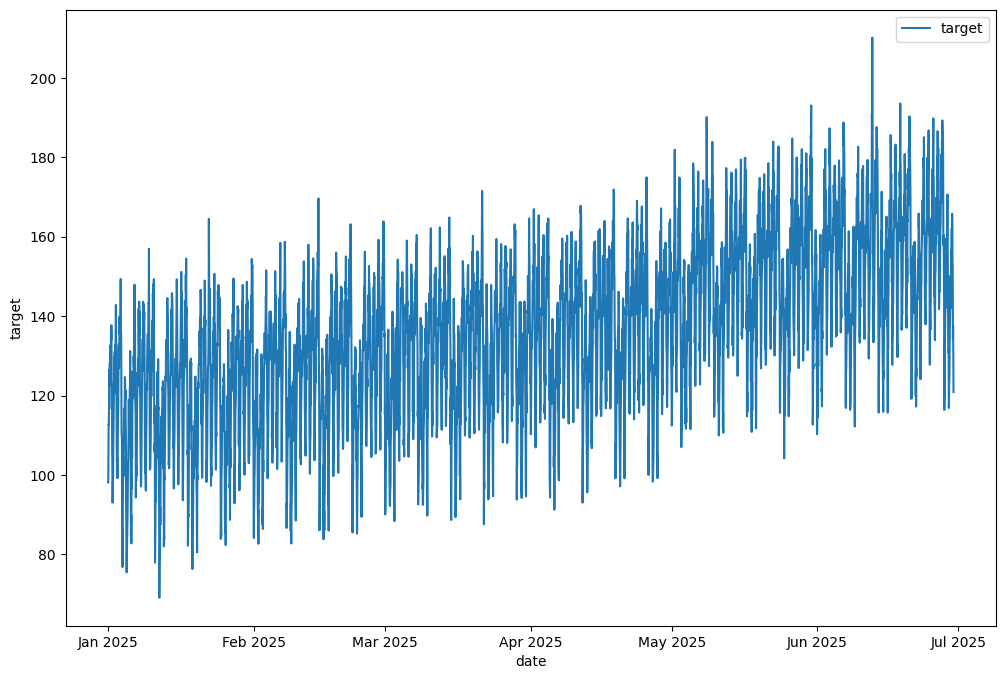

In [42]:
plt.figure(figsize=(12, 8))
plt.plot(df['date'], df['target'], label='target')

ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

plt.xlabel('date')
plt.ylabel('target')
plt.grid(False)
plt.legend()
plt.show()

## Комментарии датасета

Можем заметить тренд на увеличение примерно с 110 до 160 среднего, выбросы присутствуют, но их кол-во незначительно

In [43]:
def make_new_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    lags = [1, 7, 14]
    for lag in lags:
        df[f'lag_{lag}'] = df['target'].shift(lag)

    df['rolling_mean_7'] = df['target'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(7).std()

    date_series: pd.Series = pd.to_datetime(df['date'])
    df['weekday'] = date_series.dt.dayofweek

    df['sin_weekday'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['cos_weekday'] = np.cos(2 * np.pi * df['weekday'] / 7)

    df = df.drop(columns=['weekday'])

    df = df.dropna()

    return df

df = make_new_features(df)
df.head(5)

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,sin_weekday,cos_weekday
14,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,0.974928,-0.222521
15,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,0.974928,-0.222521
16,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,0.974928,-0.222521
17,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,0.974928,-0.222521
18,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,0.974928,-0.222521


In [44]:
def temporal_split(df: pd.DataFrame, train_size: float, val_size: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.sort_values('date').reset_index(drop=True)

    n = len(df)
    train_end = int(n * train_size)
    val_end = int(n * val_size) + train_end

    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df, train_size=0.7, val_size=0.15)

print('train shape:', train_df.shape)
print('val shape:', val_df.shape)
print('test shape:', test_df.shape)

train shape: (3014, 9)
val shape: (645, 9)
test shape: (647, 9)


## Why random split is not suitable for this task

Random split перемешивает временной ряд и создает утечку, в то же время temporal split распределяет временной ряд на 3 не пересекающихся отрезка, из-за чего утечки нет

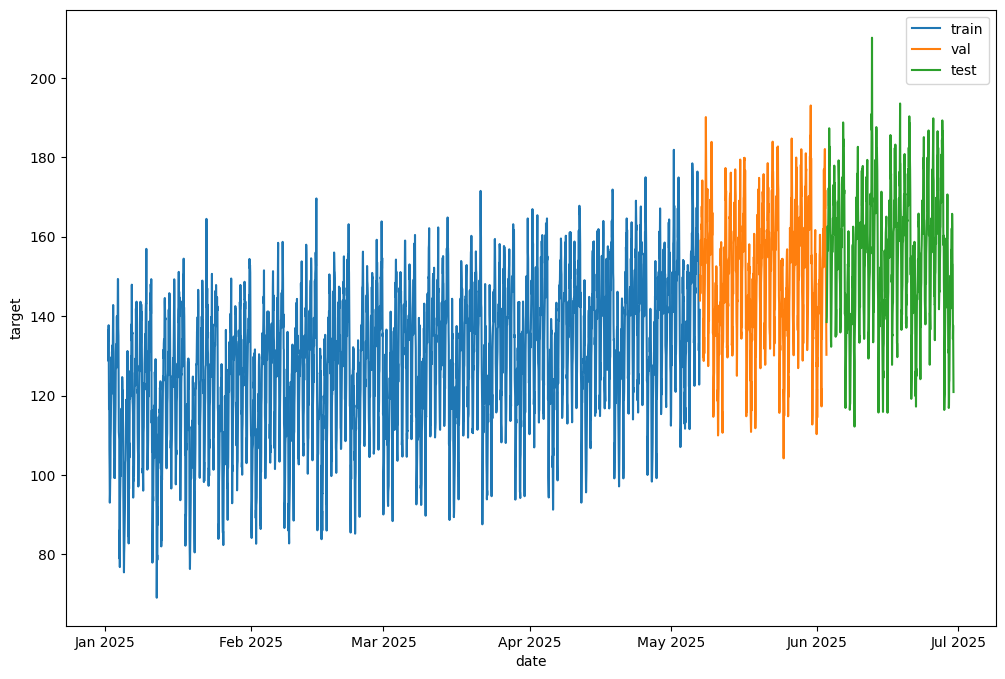

In [45]:
plt.figure(figsize=(12, 8))

plt.plot(train_df['date'], train_df['target'], label='train')
plt.plot(val_df['date'], val_df['target'], label='val')
plt.plot(test_df['date'], test_df['target'], label='test')

ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

plt.legend()
plt.xlabel('date')
plt.ylabel('target')
plt.grid(False)
plt.savefig('./artifacts/figures/series_split.png', dpi=300)
plt.show()

In [46]:
train_df, val_df, test_df = train_df.drop(columns=['date']), val_df.drop(columns=['date']), test_df.drop(columns=['date'])

In [47]:
train_X = train_df.drop(columns=['target'])
train_Y = train_df['target']

val_X = val_df.drop(columns=['target'])
val_Y = val_df['target']

test_X = test_df.drop(columns=['target'])
test_Y = test_df['target']

train_X

,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,sin_weekday,cos_weekday
0,125.04,126.01,98.14,126.445714,3.275621,0.974928,-0.222521
1,128.87,122.38,98.07,126.854286,3.388632,0.974928,-0.222521
2,136.40,128.28,104.70,128.857143,4.318919,0.974928,-0.222521
3,133.85,124.43,112.81,129.652857,4.691868,0.974928,-0.222521
4,137.71,126.35,112.62,131.550000,4.907936,0.974928,-0.222521
...,...,...,...,...,...,...,...
3009,131.33,163.32,155.22,151.214286,12.159242,0.781831,0.623490
3010,133.29,153.98,158.28,146.924286,12.469870,0.974928,-0.222521
3011,122.76,160.61,167.31,142.464286,14.876572,0.974928,-0.222521
3012,129.46,158.41,156.98,138.014286,13.096446,0.974928,-0.222521


In [48]:
scaler = StandardScaler()
train_scaler = scaler.fit_transform(train_X)
val_scaler = scaler.transform(val_X)
test_scaler = scaler.transform(test_X)

In [49]:
def make_windows(
        X: pd.DataFrame | np.ndarray,
        Y: pd.DataFrame | np.ndarray,
        window_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    if isinstance(X, pd.Series):
        X = X.to_numpy()
    if isinstance(Y, pd.Series):
        Y = Y.to_numpy()

    X_windows = []
    Y_windows = []

    for i in range(len(X) - window_size):
        X_windows.append(X[i:i + window_size])
        Y_windows.append(Y[i + window_size])

    return np.array(X_windows), np.array(Y_windows)


class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, X: torch.tensor, Y: np.ndarray) -> None:
        self.X = X
        self.Y = torch.tensor(Y, dtype=torch.float)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, item):
        return self.X[item], self.Y[item]


def train_one_epoch(
        model: nn.Module,
        optimizer: optim.Optimizer,
        criterion: nn.Module,
        loader: torch.utils.data.DataLoader,
        device: str,
) -> tuple[float, float]:
    model.train()

    total_loss, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(x).squeeze(-1)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

    return total_loss / total, total


@torch.no_grad()
def evaluate(
        model: nn.Module,
        criterion: nn.Module,
        loader: torch.utils.data.DataLoader,
        device: torch.device,
) -> tuple[float, float]:
    model.eval()

    loss, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        preds = model(x).squeeze(-1)
        loss += criterion(preds, y).item() * y.size(0)
        total += y.size(0)

    return loss / total, total


def fit(
        model: nn.Module,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
        train_loader: torch.utils.data.DataLoader,
        val_loader: torch.utils.data.DataLoader,
        epochs: int,
        device: str,
        verbose: bool = False,
):
    model.train()
    model.to(device)

    history = {
        'train_loss': [],
        'val_loss': [],
    }

    for epoch in range(epochs):

        train_loss, train_total = train_one_epoch(
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            loader=train_loader,
            device=device,
        )

        val_loss, val_total = evaluate(
            model=model,
            criterion=criterion,
            loader=val_loader,
            device=device,
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f'epoch: {epoch:02d} || train_loss: {train_loss:0.3f} || val_loss: {val_loss:0.3f}')


    return history

def metrics(y_pred, y_true):
    MAE = np.abs(y_pred - y_true).mean()
    RMSE = np.sqrt(np.mean((y_pred - y_true) ** 2))
    MAPE = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {'mae': MAE, 'rmse': RMSE, 'mape': MAPE}

In [50]:
RUNS = pd.DataFrame(columns=[
    'experiment_id',
    'task',
    'dataset',
    'seed',
    'split_summary',
    'window_size',
    'horizon',
    'model_summary',
    'features_summary',
    'scaler',
    'optimizer',
    'lr',
    'epochs_trained',
    'best_val_mae',
    'best_val_rmse',
    'best_val_mape',
    'test_mae',
    'test_rmse',
    'test_mape',
    'notes',
])

def save_runs(runs: pd.DataFrame, path: str = './artifacts/runs.csv') -> None:
    runs.to_csv(path, index=False)

def save_to_runs(run: pd.DataFrame, runs: pd.DataFrame) -> pd.DataFrame:
    runs = pd.concat([run, runs], ignore_index=True)
    return runs

## Experiment B1

Naive last model which predict the current prediction like last day's targets

In [51]:
preds = train_X['lag_1']

metrics_b1 = metrics(preds, train_Y)

preds = val_X['lag_1']
metrics_b1_val = metrics(preds, val_Y)

print(metrics_b1)
print(metrics_b1_val)

{'mae': np.float64(6.24991705374917), 'rmse': np.float64(7.981430723674476), 'mape': np.float64(5.023529377869361)}
{'mae': np.float64(6.4406201550387605), 'rmse': np.float64(8.203475383768334), 'mape': np.float64(4.392183983392367)}


## Experiment B2

Baseline with rolling window with size of 7

In [52]:
preds = train_X['rolling_mean_7']

metrics_b2 = metrics(preds, train_Y)

preds = val_X['rolling_mean_7']
metrics_b2_val = metrics(preds, val_Y)

print(metrics_b2)
print(metrics_b2_val)

{'mae': np.float64(12.744145890605745), 'rmse': np.float64(15.265297349086268), 'mape': np.float64(10.568873243046955)}
{'mae': np.float64(12.726609080841639), 'rmse': np.float64(15.242136544735018), 'mape': np.float64(8.830313050776448)}


## Experiment B3

Ridge with standard scaller

In [53]:
model = Ridge(
    random_state=SEED,
)

model.fit(X=train_scaler, y=train_Y)

preds = model.predict(val_scaler)
metrics_b3 = metrics(preds, val_Y)
print(metrics_b3)

{'mae': np.float64(7.262053029499181), 'rmse': np.float64(8.807937427577684), 'mape': np.float64(4.841361202170742)}


## Experiment R1

GRU model

In [54]:
class Model(nn.Module):
    def __init__(self, input_size, output_size, num_layers, dropout_p):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=output_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(output_size, 1)

    def forward(self, x):
        _, hidden = self.gru(x)
        x = self.fc(hidden[-1])
        return x.squeeze(-1)

In [55]:
model = Model(7, 32, 1, 0).to(device)
optimizer = optim.Adam(params=model.parameters(), lr=1e-3)
criterion = nn.L1Loss()

In [56]:
x_train_wins, y_trains_wins = make_windows(train_scaler ,train_Y.values, window_size=32)
x_train_wins = torch.tensor(x_train_wins, dtype=torch.float32).to(device)
x_val_wins, y_vals_wins = make_windows(val_scaler, val_Y.values, window_size=32)
x_val_wins = torch.tensor(x_val_wins, dtype=torch.float32).to(device)

train_dataset = CustomDataset(x_train_wins, y_trains_wins)
val_dataset = CustomDataset(x_val_wins, y_vals_wins)

train_loader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32)

In [57]:
x_train_wins.shape

torch.Size([2982, 32, 7])

In [58]:
history = fit(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=80,
    device=device,
    verbose=True,
)

epoch: 00 || train_loss: 126.584 || val_loss: 145.342
epoch: 01 || train_loss: 121.011 || val_loss: 140.965
epoch: 02 || train_loss: 117.165 || val_loss: 137.375
epoch: 03 || train_loss: 113.682 || val_loss: 133.971
epoch: 04 || train_loss: 110.327 || val_loss: 130.656
epoch: 05 || train_loss: 107.040 || val_loss: 127.393
epoch: 06 || train_loss: 103.794 || val_loss: 124.163
epoch: 07 || train_loss: 100.577 || val_loss: 120.958
epoch: 08 || train_loss: 97.381 || val_loss: 117.770
epoch: 09 || train_loss: 94.200 || val_loss: 114.595
epoch: 10 || train_loss: 91.031 || val_loss: 111.432
epoch: 11 || train_loss: 87.872 || val_loss: 108.277
epoch: 12 || train_loss: 84.720 || val_loss: 105.129
epoch: 13 || train_loss: 81.575 || val_loss: 101.987
epoch: 14 || train_loss: 78.436 || val_loss: 98.849
epoch: 15 || train_loss: 75.301 || val_loss: 95.716
epoch: 16 || train_loss: 72.170 || val_loss: 92.587
epoch: 17 || train_loss: 69.042 || val_loss: 89.460
epoch: 18 || train_loss: 65.917 || val_los

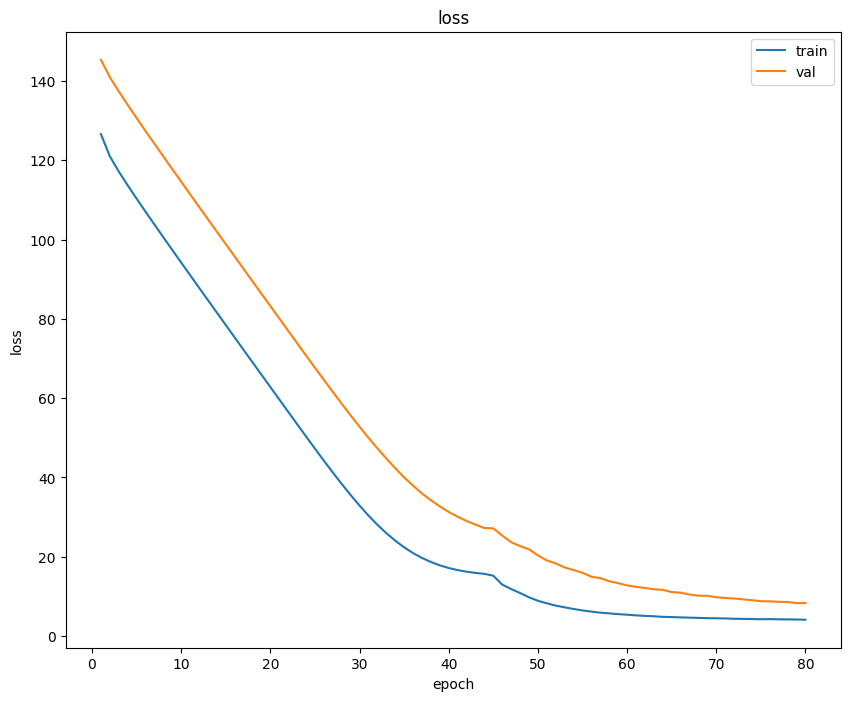

In [59]:
plt.figure(figsize=(10, 8))
epochs = torch.arange(1, len(history['train_loss']) + 1)
plt.plot(epochs, history['train_loss'], label='train')
plt.plot(epochs, history['val_loss'], label='val')
plt.title("loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()
plt.savefig('./artifacts/figures/gru_learning_curves.png')
plt.show()

In [60]:
model.eval()
with torch.no_grad():
    preds = model(x_val_wins).cpu().numpy()
    y_true = y_vals_wins

metrics_r1 = metrics(preds, y_vals_wins)
print(metrics_r1)

{'mae': np.float64(8.304198783638038), 'rmse': np.float64(10.72348899387065), 'mape': np.float64(5.378467203410469)}


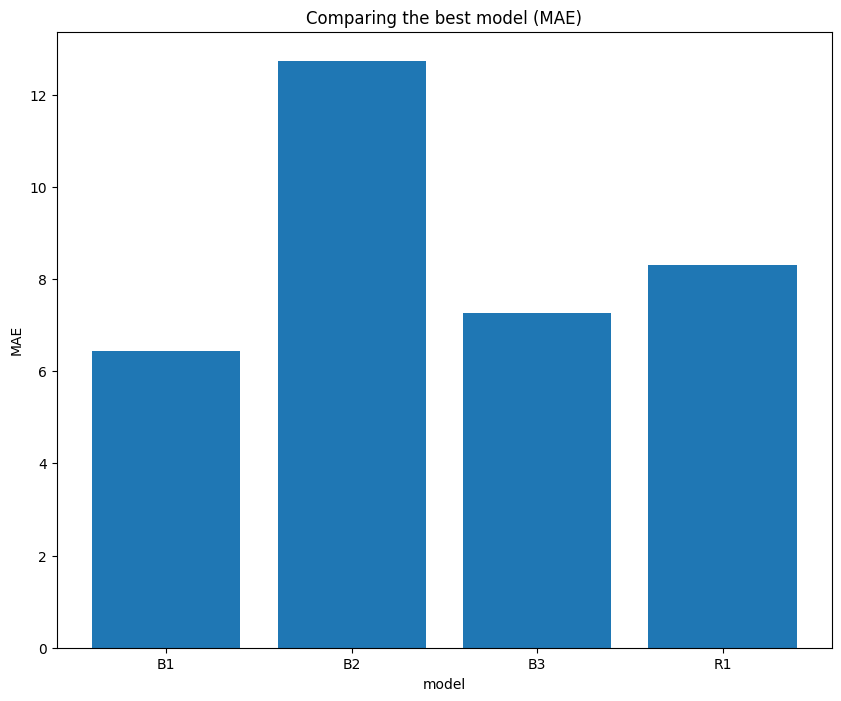

In [61]:
plt.figure(figsize=(10, 8))
plt.bar(['B1', 'B2', 'B3', 'R1'], [metrics_b1_val['mae'], metrics_b2_val['mae'], metrics_b3['mae'], metrics_r1['mae']])
plt.savefig('./artifacts/figures/baselines_compare.png')
plt.ylabel('MAE')
plt.xlabel('model')
plt.title('Comparing the best model (MAE)')
plt.show()

### Best model is B1 experiment's model

In [62]:
torch.save(model.state_dict(), './artifacts/best_gru.pt')

In [64]:
best_model = {
    'model': 'GRU',
    'optimizer': 'Adam',
    'criterion': 'L1Loss',
    'epochs': 80,
    'device': device.type,
    'seed': SEED,
    'window_size': 32,
    'batch_size': 32,
    'scaler': 'StandardScaler',
    'configurations': {
        'input_size': 7,
        'num_layers': 1,
        'dropout_p': 0.0,
        'batch_size': 32,
        'learning_rate': 1e-3,
        'hidden_size': 32,
    }
}

with open('./artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_model, f, ensure_ascii=False, indent=4)

In [65]:
test_preds = test_X['lag_1']
test_metrics = metrics(test_preds, test_Y)
print(test_metrics)

{'mae': np.float64(6.34095826893354), 'rmse': np.float64(8.060187080029195), 'mape': np.float64(4.146298982666311)}


In [66]:
def add_run(runs_df, experiment_id, task, dataset, seed, split_summary, window_size, horizon,
            model_summary, features_summary, scaler, optimizer, lr, epochs_trained,
            best_val_mae, best_val_rmse, best_val_mape, test_mae=None, test_rmse=None, test_mape=None, notes=None):
    """Добавляет новую строку в DataFrame RUNS"""
    new_row = pd.DataFrame({
        'experiment_id': [experiment_id],
        'task': [task],
        'dataset': [dataset],
        'seed': [seed],
        'split_summary': [split_summary],
        'window_size': [window_size],
        'horizon': [horizon],
        'model_summary': [model_summary],
        'features_summary': [features_summary],
        'scaler': [scaler],
        'optimizer': [optimizer],
        'lr': [lr],
        'epochs_trained': [epochs_trained],
        'best_val_mae': [best_val_mae],
        'best_val_rmse': [best_val_rmse],
        'best_val_mape': [best_val_mape],
        'test_mae': [test_mae],
        'test_rmse': [test_rmse],
        'test_mape': [test_mape],
        'notes': [notes],
    })
    return pd.concat([runs_df, new_row], ignore_index=True)


# Используем функцию для каждого эксперимента
RUNS = add_run(RUNS,
               experiment_id='B1',
               task='forecasting',
               dataset='S12-hw-dataset.csv',
               seed=SEED,
               split_summary='train: 70% | val: 15% | test: 15%, (temporal split, without shuffle)',
               window_size=1,
               horizon=1,
               model_summary='Baseline 1',
               features_summary='lag_1',
               scaler='StandardScaler',
               optimizer=None,
               lr=None,
               epochs_trained=None,
               best_val_mae=metrics_b1_val['mae'],
               best_val_rmse=metrics_b1_val['rmse'],
               best_val_mape=metrics_b1_val['mape'],
               test_mae=test_metrics['mae'],
               test_rmse=test_metrics['rmse'],
               test_mape=test_metrics['mape'],
               notes='naive baseline last value'
)

RUNS = add_run(RUNS,
               experiment_id='B2',
               task='forecasting',
               dataset='S12-hw-dataset.csv',
               seed=SEED,
               split_summary='train: 70% | val: 15% | test: 15%, (temporal split, without shuffle)',
               window_size=7,
               horizon=1,
               model_summary='Baseline 2',
               features_summary='rolling_mean_7',
               scaler='StandardScaler',
               optimizer=None,
               lr=None,
               epochs_trained=None,
               best_val_mae=metrics_b2_val['mae'],
               best_val_rmse=metrics_b2_val['rmse'],
               best_val_mape=metrics_b2_val['mape'],
               test_mae=np.nan,
               test_rmse=np.nan,
               test_mape=np.nan,
               notes='moving average baseline',
)

RUNS = add_run(RUNS,
               experiment_id='B3',
               task='forecasting',
               dataset='S12-hw-dataset.csv',
               seed=SEED,
               split_summary='train: 70% | val: 15% | test: 15%, (temporal split, without shuffle)',
               window_size=32,
               horizon=1,
               model_summary='Ridge',
               features_summary='lag_7, lag_14, lag_1, rolling_mean_7, rolling_std_7, sin_weekday, cos_weekday',
               scaler='StandardScaler',
               optimizer=None,
               lr=None,
               epochs_trained=None,
               best_val_mae=metrics_b3['mae'],
               best_val_rmse=metrics_b3['rmse'],
               best_val_mape=metrics_b3['mape'],
               test_mae=np.nan,
               test_rmse=np.nan,
               test_mape=np.nan,
               notes='Ridge baseline',
)

RUNS = add_run(RUNS,
               experiment_id='R1',
               task='forecasting',
               dataset='S12-hw-dataset.csv',
               seed=SEED,
               split_summary='train: 70% | val: 15% | test: 15%, (temporal split, without shuffle)',
               window_size=32,
               horizon=1,
               model_summary='GRU + Linear',
               features_summary='lag_7, lag_14, lag_1, rolling_mean_7, rolling_std_7, sin_weekday, cos_weekday',
               scaler='StandardScaler',
               optimizer='Adam',
               lr='1e-3',
               epochs_trained='80',
               best_val_mae=metrics_r1['mae'],
               best_val_rmse=metrics_r1['rmse'],
               best_val_mape=metrics_r1['mape'],
               test_mae=np.nan,
               test_rmse=np.nan,
               test_mape=np.nan,
)

save_runs(RUNS, './artifacts/runs.csv')
RUNS

/var/folders/t7/8q1snzfs15d4f28v56qswrkh0000gn/T/ipykernel_17232/3465249403.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([runs_df, new_row], ignore_index=True)


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train: 70% | val: 15% | test: 15%, (temporal s...",1,1,Baseline 1,lag_1,StandardScaler,None,None,None,6.440620,8.203475,4.392184,6.340958,8.060187,4.146299,naive baseline last value
1,B2,forecasting,S12-hw-dataset.csv,42,"train: 70% | val: 15% | test: 15%, (temporal s...",7,1,Baseline 2,rolling_mean_7,StandardScaler,None,None,None,12.726609,15.242137,8.830313,NaN,NaN,NaN,moving average baseline
2,B3,forecasting,S12-hw-dataset.csv,42,"train: 70% | val: 15% | test: 15%, (temporal s...",32,1,Ridge,"lag_7, lag_14, lag_1, rolling_mean_7, rolling_...",StandardScaler,None,None,None,7.262053,8.807937,4.841361,NaN,NaN,NaN,Ridge baseline
3,R1,forecasting,S12-hw-dataset.csv,42,"train: 70% | val: 15% | test: 15%, (temporal s...",32,1,GRU + Linear,"lag_7, lag_14, lag_1, rolling_mean_7, rolling_...",StandardScaler,Adam,1e-3,80,8.304199,10.723489,5.378467,NaN,NaN,NaN,None


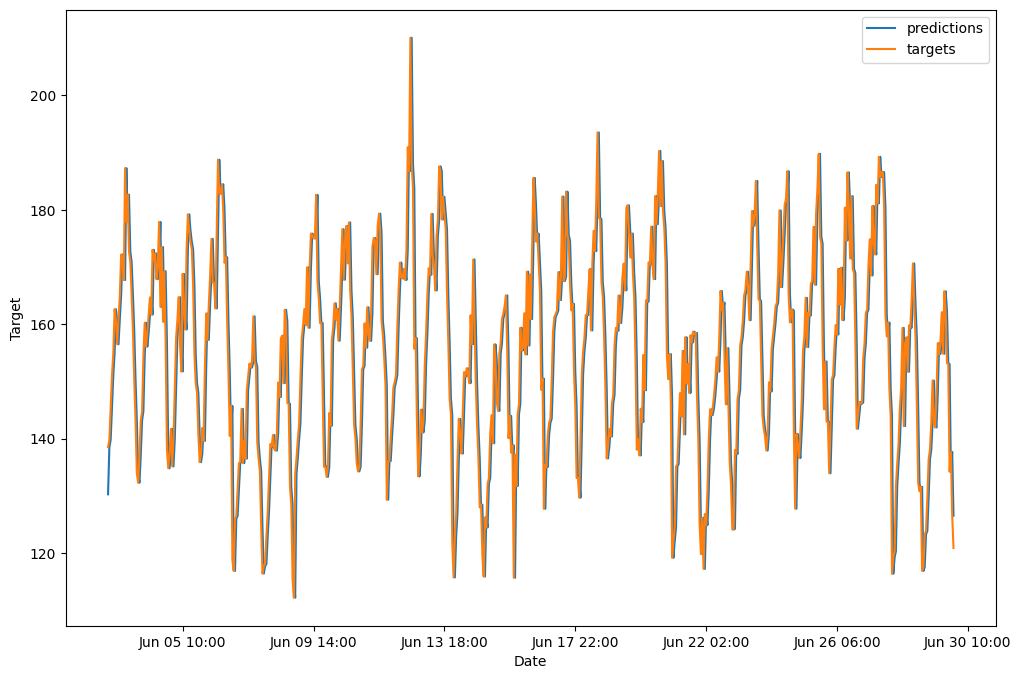

In [67]:
train_df, val_df, test_df = temporal_split(df, 0.7, 0.15)
test_df['date'] = pd.to_datetime(test_df['date'])
plt.figure(figsize=(12, 8))
plt.plot(test_df['date'], test_preds, label='predictions')
plt.plot(test_df['date'], test_df['target'], label='targets')

ax = plt.gca()

ax.xaxis.set_major_locator(HourLocator(interval=100))
ax.xaxis.set_major_formatter(DateFormatter('%b %d %H:%M'))

plt.grid(False)
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.savefig('./artifacts/figures/best_forecast_test.png')
plt.show()


Мы правильно отработали с данными, избежав leakage, так как при получении новых признаков, мы делали shift, тем самым сдвигаясь влево (в прошлое грубо говоря) и наша модель не имела доступ к данным из будущего